
# BIOINF 580 — Lab 2.5
### 10/05/2026
### GSI: Morgen Henry



---

# 0. Setup Reminder

Before starting this lab, please make sure you are in the correct Python environment.

1. **Activate the conda environment** (in your terminal or Anaconda Prompt):
   ```bash
   conda activate bioinf580
   ```

2. **Select the Jupyter kernel**: when this notebook is open, go to the top-right corner of JupyterLab/Notebook and choose  
   **bioinf580** as the kernel.

3. **Clone the Higuchi Fractal Dimension repo** into the folder where you want to keep it.
   ```bash
   git clone https://github.com/inuritdino/HiguchiFractalDimension.git
   ```

4. **Install the PyWavelets package if you haven’t installed it last time**
   ```bash
   conda install -c conda-forge pywavelets
   ```

5. **Import the required packages**: run the code cell below to load all libraries needed for this lab.

In [3]:
## Import required packages
import os, sys

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from numpy.fft import rfft, rfftfreq
import pywt

# Python needs the folder that CONTAINS the cloned repo on its path (not the repo folder itself).
# If you cloned it next to this notebook, leave this as ".". Otherwise, point it at the parent folder,
# e.g. HFD_PARENT = "~/code" if the repo lives at ~/code/HiguchiFractalDimension
HFD_PARENT = "."
sys.path.insert(0, os.path.abspath(os.path.expanduser(HFD_PARENT)))
import HiguchiFractalDimension as hfd

print("Environment ready — all packages imported.")

Environment ready — all packages imported.


In [5]:
# --- helper functions ---
def gaussian(x, x0, sigma):
    return np.exp(-np.power((x - x0) / sigma, 2.0) / 2.0)

def make_chirp(t, t0, a):
    """Chirp whose instantaneous frequency is exactly f(t) = (a*(t + t0))**2."""
    frequency = (a * (t + t0)) ** 2
    phase = 2 * np.pi * (a ** 2) * ((t + t0) ** 3 - t0 ** 3) / 3   # 2π ∫ f dt
    return np.sin(phase), frequency

# --- generate signal ---
fs = 2000                                  # sampling rate (Hz)
time = np.arange(0, 1, 1 / fs)             # 1 s, 2000 samples
chirp1, frequency1 = make_chirp(time, 0.2, 9)
chirp2, frequency2 = make_chirp(time, 0.1, 5)
chirp = chirp1 + 0.6 * chirp2
chirp *= gaussian(time, 0.5, 0.2)          # apply Gaussian window

## 2.4 Discrete Wavelet Transform (DWT)

- The Discrete Wavelet Transform (DWT) is an analysis tool that decomposes a time-domain signal into frequency components, similar in spirit to the Fourier Transform.

- However, instead of producing a dense, redundant representation like the Continuous Wavelet Transform, the DWT provides a compact, multi-resolution hierarchy of approximation (low-frequency) and detail (high-frequency) coefficients.

- This decomposition is efficiently computed using the Mallat pyramidal algorithm, also known as a Quadrature Mirror Filter (QMF) bank, where the signal is repeatedly passed through pairs of low-pass and high-pass filters followed by downsampling.

- As a result, the DWT captures both time and frequency information in a sparse, hierarchical structure that allows for perfect reconstruction of the original signal.

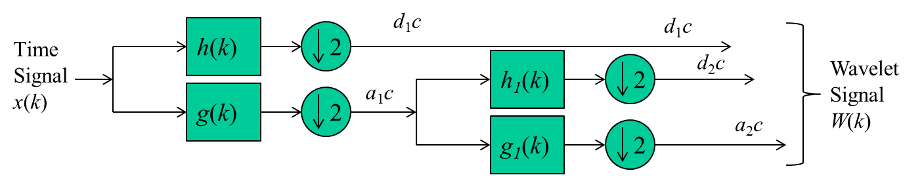

### 2.4.1 Discrete Wavelet Transform (DWT) and its inverse (IDWT) in PyWavelets

### (a). Multilevel Discrete Wavelet Transform (DWT) using `wavedec`

📚 **Reference**  
- [Multilevel 1D DWT](https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html)

#### Function

`pywt.wavedec(data, wavelet, level=None)`

#### Parameters

- **`data`**: *1-D array*  
  The input signal to be decomposed.

- **`wavelet`**: *string or Wavelet object*  
  The discrete wavelet to use (e.g., `"db4"`, `"haar"`).

- **`level`**: *int or None*  
  The number of decomposition levels.  
  If `None`, decomposition continues until the maximum possible level.

#### Returns

- **`coeffs`** (*list*)  
  `[cA_n, cD_n, cD_{n-1}, ..., cD_1]`  
  - `cA_n`: Approximation coefficients at the final level  
  - `cD_i`: Detail coefficients at level *i*

#### Example:

In [6]:
from pywt import wavedec

coeffs = wavedec([1,2,3,4,5,6,7,8], 'db1', level=2)
cA2, cD2, cD1 = coeffs

print("cD1 =", cD1)
print("cD2 =", cD2)
print("cA2 =", cA2)


cD1 = [-0.70710678 -0.70710678 -0.70710678 -0.70710678]
cD2 = [-2. -2.]
cA2 = [ 5. 13.]


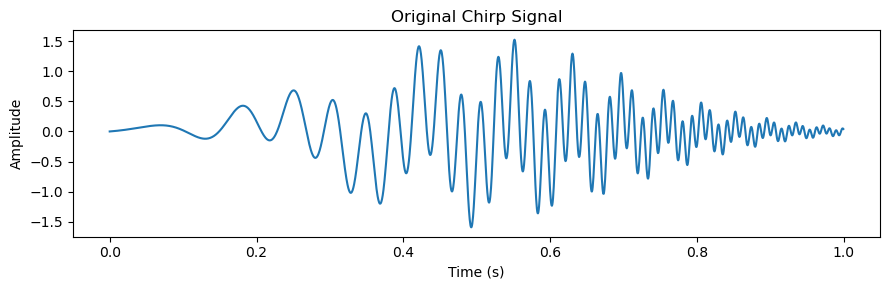

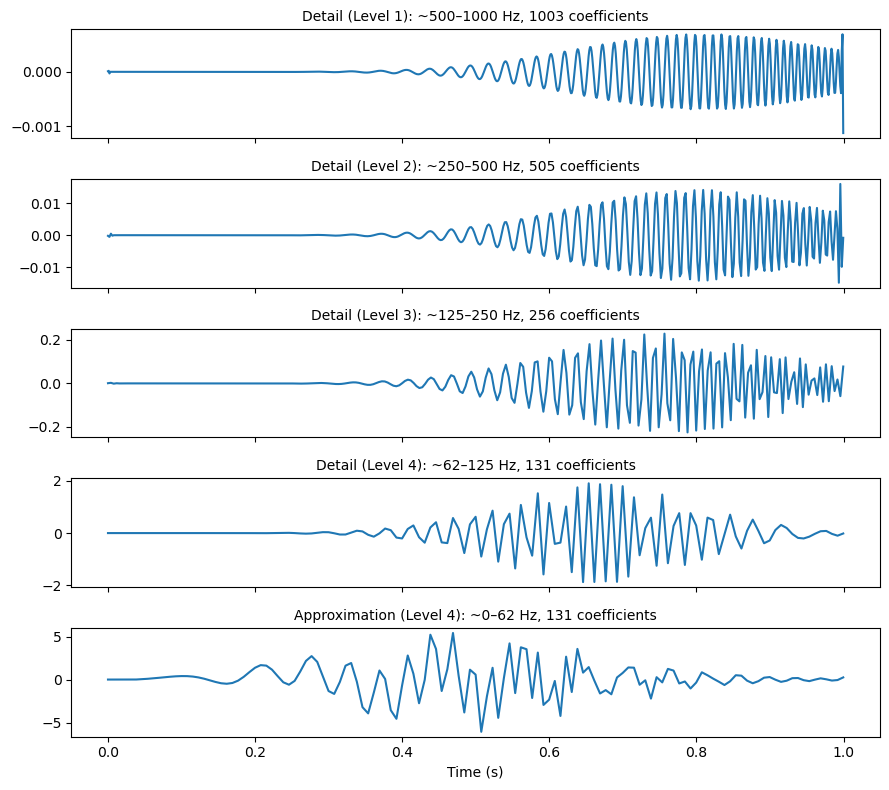

In [7]:
# Reuse `chirp`, `time`, and `fs` from the CWT example above

# Choose wavelet and perform 4-level decomposition
w = pywt.Wavelet('db4')
coeffs = pywt.wavedec(chirp, wavelet=w, level=4)
cA4, cD4, cD3, cD2, cD1 = coeffs

# --- plot signal ---
plt.figure(figsize=(9, 3))
plt.plot(time, chirp, color="tab:blue")
plt.title("Original Chirp Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# --- plot coefficients on a shared time axis, labeled with their frequency bands ---
# Each level halves the band: detail level j covers roughly fs/2^(j+1) to fs/2^j Hz
labels = [("Approximation (Level 4)", cA4, 0, fs / 2**5)] + [
    (f"Detail (Level {j})", c, fs / 2**(j + 1), fs / 2**j)
    for j, c in zip([4, 3, 2, 1], [cD4, cD3, cD2, cD1])
]
fig, axes = plt.subplots(5, 1, figsize=(9, 8), sharex=True)
for ax, (name, c, lo, hi) in zip(axes, labels[::-1]):          # Level 1 on top
    ax.plot(np.linspace(0, time[-1], len(c)), c)
    ax.set_title(f"{name}: ~{lo:.0f}–{hi:.0f} Hz, {len(c)} coefficients", fontsize=10)
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

Compare with the scalogram: as the faster chirp's frequency rises past ~62 Hz (around t ≈ 0.6 s), its energy moves from the approximation band into Detail Level 4. Watch the y-axes: Levels 1–3 are orders of magnitude smaller, because the chirp never exceeds ~117 Hz. What little appears there is leakage, since real wavelet filters don't split the spectrum perfectly at the octave boundaries. Each level also has about half as many coefficients as the one below it (the downsampling step, plus a few extra from boundary padding), which is why the DWT is compact but its bands are coarse, fixed octaves.


### (b). Maximum Decomposition Level (dwt_max_level)

📚 **Reference**  
- [Maximum DWT Level](https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html#pywt.dwt_max_level)

#### Function

`pywt.dwt_max_level(data_len, filter_len)`

#### Parameters

- **`data_len`**: *int*  
  The length of the input signal.

- **`filter_len`**: *int*  
  The length of the wavelet filter (use `pywt.Wavelet(wavelet).dec_len`).

#### Returns

- **`max_level`** (*int*)  
  The maximum number of decomposition levels allowed for the given signal length and wavelet filter length.

#### Example:

In [8]:
w = pywt.Wavelet('db4')
print(pywt.dwt_max_level(data_len=len(chirp), filter_len=w.dec_len))

8


### (c). Multilevel Reconstruction (iDWT) using `waverec`

📚 **Reference**  
- [Multilevel 1D Reconstruction](https://pywavelets.readthedocs.io/en/latest/ref/idwt-inverse-discrete-wavelet-transform.html)

#### Function

`pywt.waverec(coeffs, wavelet)`

#### Parameters

- **`coeffs`**: *list*  
  Coefficients returned by `pywt.wavedec`, in the form  
  `[cA_n, cD_n, cD_{n-1}, ..., cD_1]`.

- **`wavelet`**: *string or Wavelet object*  
  The same wavelet used during decomposition (e.g., `"db4"`, `"sym5"`).

#### Returns

- **`rec`**: *1-D ndarray*  
  The reconstructed signal, with length equal to the original input (within boundary effects).

#### Example:

Max reconstruction error: 1.11e-15


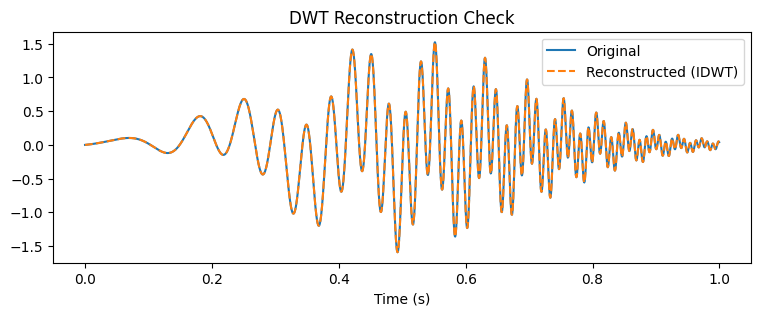

In [18]:
# --- Inverse DWT (reconstruction) ---
chirp_rec = pywt.waverec(coeffs, wavelet=w)
chirp_rec = chirp_rec[:len(chirp)]        # waverec can return one extra sample for odd-length inputs

print(f"Max reconstruction error: {np.max(np.abs(chirp - chirp_rec)):.2e}")

plt.figure(figsize=(9, 3))
plt.plot(time, chirp, label="Original")
plt.plot(time, chirp_rec, '--', label="Reconstructed (IDWT)")
plt.title("DWT Reconstruction Check")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

### 2.4.2 Features Derived from the Discrete Wavelet Transform (DWT)

Once a signal is decomposed using the Discrete Wavelet Transform (DWT),  
statistical and energy-based features can be computed from the approximation and detail coefficients.  
These features are commonly used in **signal processing, biomedical engineering, and pattern recognition**.

#### Key Features

- **Energy**:  
  Represents the overall power of the signal in a subband.  
  Useful for distinguishing low- vs. high-frequency dominance.

- **Mean**:  
  The average value of the coefficients, indicating central tendency. (For detail coefficients this is usually close to 0, so it is often less informative than energy or variance.)

- **Variance**:  
  Measures the spread or variability of the coefficients.

- **Standard Deviation**:  
  Quantifies dispersion around the mean, complementing variance.

- **Skewness**:  
  Indicates asymmetry of the coefficient distribution.

- **Kurtosis**:  
  Measures the “tailedness” of the distribution (sharp vs. flat).

- **Entropy**:  
  Reflects how spread out the energy is. A common definition is the Shannon entropy of the normalized squared coefficients, $-\sum_i p_i \log p_i$ with $p_i = c_i^2 / \sum_j c_j^2$.  
  Higher entropy = energy spread over many coefficients; lower = energy concentrated in a few.

- **Maximum and Minimum Values**:  
  Extreme coefficient values, corresponding to peak amplitudes in the signal.
By computing these features across multiple decomposition levels (e.g., from cA and each cD),  
you obtain a **multi-resolution feature set** that captures both frequency-specific and statistical properties of the signal.

---

In [19]:
def dwt_features(signal_1d, wavelet="db4", level=4):
    """Per-subband statistical and energy features from a multilevel DWT."""
    coeffs = pywt.wavedec(signal_1d, wavelet, level=level)
    names = [f"A{level}"] + [f"D{j}" for j in range(level, 0, -1)]
    total_energy = sum(np.sum(c ** 2) for c in coeffs)
    rows = []
    for name, c in zip(names, coeffs):
        energy = np.sum(c ** 2)
        p = c ** 2 / energy if energy > 0 else np.zeros_like(c)
        p = p[p > 0]
        rows.append({
            "subband": name,
            "energy": energy,
            "rel_energy": energy / total_energy,
            "mean": np.mean(c),
            "std": np.std(c),
            "skewness": stats.skew(c),
            "kurtosis": stats.kurtosis(c),
            "entropy": -np.sum(p * np.log(p)),
            "max": np.max(c),
            "min": np.min(c),
        })
    return pd.DataFrame(rows).set_index("subband")

dwt_features(chirp).round(3)

,energy,rel_energy,mean,std,skewness,kurtosis,entropy,max,min
subband,,,,,,,,,
A4,412.514,0.855,0.059,1.774,-0.200,2.013,3.626,5.423,-6.071
D4,68.022,0.141,-0.002,0.721,-0.070,1.576,3.588,1.911,-1.882
D3,1.854,0.004,0.000,0.085,-0.189,1.024,4.387,0.229,-0.226
D2,0.015,0.000,-0.000,0.005,0.006,0.925,5.066,0.016,-0.015
D1,0.000,0.000,-0.000,0.000,-0.054,1.085,5.734,0.001,-0.001


**Try it**
- Run `dwt_features` on white noise (`x`) and on Brownian motion (`y`) from Section 1 of the original lab. How does the relative energy across subbands differ, and how does that relate to their HFD values?
- Increase `level` to `pywt.dwt_max_level(...)`. Which subbands still carry meaningful energy for the chirp?


# Lab 2 Overall Takeaways:

**Scope (Lab):** You explored three pillars of 1D signal analysis:

1) **Fractal Dimension (Higuchi)**  
   - *Idea:* quantified geometric roughness/complexity (FD ∈ [1, 2]).  
   - *You learned:* how to compute HFD with the library, implement it from scratch, verify it on smooth vs. noisy signals, and track it over time with sliding windows.  
   - **Feature ideas (you used or can extend):**  
     - FD (single scalar per segment)  
     - FD vs. different $k_{\max}$ (stability curve) 

2) **Continuous Wavelet Transform (CWT)**  
   - *Idea:* produced a time–frequency map with adaptive resolution via scaled/shifted mother wavelets.  
   - *You learned:* to choose a frequency range, map to scales, compute CWT, and interpret scalograms.  
   - **Feature ideas:**  
     - Band energies from scalograms (e.g., 1–4, 4–12, 12–30 Hz)  
     - Temporal stats per band (mean, max, variance, burst count)

3) **Discrete Wavelet Transform (DWT)**  
   - *Idea:* compact, dyadic multiresolution filter bank (approximation + details).  
   - *You learned:* to pick wavelet/levels (via `dwt_max_level`), decompose with `wavedec`, visualize A/D components, and reconstruct with `waverec`.  
   - **Feature ideas:**  
     - Detail-band energies $\sum c_D^2$ per level  
     - Stats of coefficients (mean/variance/kurtosis) per level  
     - Energy ratios across levels (e.g., mid-band / low-band)

---